In [ ]:
#Installing required libraries
!pip install -q mtcnn grad-cam gradio torch torchvision scikit-learn seaborn opencv-python pyyaml
print("Dependencies installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 76.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.9 MB/s eta 0:00:00
Dependencies installed successfully!


In [ ]:
#Import libraries and set device
import os
import cv2
import math
import yaml
import torch
import shutil
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from mtcnn import MTCNN
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#unzipping the datasets from google drive
!unzip -qo "/content/drive/MyDrive/faceshape.zip" -d /content/faceshape
!unzip -qo "/content/drive/MyDrive/eyeshape.zip" -d /content/eyeshape
print("Unzipped from Google Drive!")

Unzipped from Google Drive!


In [ ]:
import os
import cv2
import yaml
import torch
import shutil
import numpy as np

FACE_PROCESSED_DIR = '/content/processed_faces'
EYE_PROCESSED_DIR = '/content/processed_eyes'

# 1. FORCE CLEAN TO START FRESH
if os.path.exists(FACE_PROCESSED_DIR):
    shutil.rmtree(FACE_PROCESSED_DIR)

# --- SMART PATH FINDER (UPDATED FOR 'training') ---
def find_training_dir(base_path):
    """Hunts down the 'training' or 'train' folder specifically"""
    for root, dirs, files in os.walk(base_path):
        # Convert to lowercase to catch 'Training', 'training', 'Train', etc.
        lower_dirs =[d.lower() for d in dirs]
        if 'training_set' in lower_dirs:
            actual_name = dirs[lower_dirs.index('training_set')]
            return os.path.join(root, actual_name)
        elif 'train' in lower_dirs:
            actual_name = dirs[lower_dirs.index('train')]
            return os.path.join(root, actual_name)
    return base_path

def find_file(base_path, filename):
    for root, dirs, files in os.walk(base_path):
        if filename in files:
            return root
    return base_path

# Locate exactly where the folders are
FACE_RAW_TRAIN_DIR = find_training_dir('/content/faceshape')
EYE_YOLO_DIR = find_file('/content/eyeshape', 'data.yaml')

print(f"Found Face Dataset at: {FACE_RAW_TRAIN_DIR}")
print(f"Found Eye Dataset at: {EYE_YOLO_DIR}")

# 2. PROPERLY COPY FACE CLASSES (oval, square, etc.)
# We map it to '/content/processed_faces/train' so PyTorch natively understands it
os.makedirs(os.path.join(FACE_PROCESSED_DIR, 'train'), exist_ok=True)
for class_folder in os.listdir(FACE_RAW_TRAIN_DIR):
    src = os.path.join(FACE_RAW_TRAIN_DIR, class_folder)
    dst = os.path.join(FACE_PROCESSED_DIR, 'train', class_folder)
    if os.path.isdir(src):
        shutil.copytree(src, dst)

print(f"Successfully copied Face shape classes to {FACE_PROCESSED_DIR}/train")

# --- YOLO TO PYTORCH CLASSIFICATION CONVERTER ---
def convert_yolo_to_classification(yolo_dir, output_dir, split='train'):
    yaml_path = os.path.join(yolo_dir, 'data.yaml')
    if not os.path.exists(yaml_path): return

    with open(yaml_path, 'r') as f:
        data_yaml = yaml.safe_load(f)
    classes = data_yaml.get('names',[])
    if isinstance(classes, dict): classes = list(classes.values())

    # Roboflow sometimes names the validation set 'valid' instead of 'val'
    img_dir = os.path.join(yolo_dir, split, 'images')
    lbl_dir = os.path.join(yolo_dir, split, 'labels')
    if not os.path.exists(img_dir): return

    for class_name in classes:
        os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

    for label_file in os.listdir(lbl_dir):
        if not label_file.endswith('.txt'): continue

        img_name = label_file.replace('.txt', '')
        img_path = None
        for ext in['.jpg', '.jpeg', '.png', '.JPG', '.PNG']:
            temp_path = os.path.join(img_dir, img_name + ext)
            if os.path.exists(temp_path):
                img_path = temp_path
                break

        if img_path is None: continue

        img = cv2.imread(img_path)
        if img is None: continue
        h, w, _ = img.shape

        with open(os.path.join(lbl_dir, label_file), 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) < 5: continue

                class_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])

                x1, y1 = int((cx - bw/2) * w), int((cy - bh/2) * h)
                x2, y2 = int((cx + bw/2) * w), int((cy + bh/2) * h)

                eye_crop = img[max(0, y1):min(h, y2), max(0, x1):min(w, x2)]
                if eye_crop.size != 0:
                    cv2.imwrite(os.path.join(output_dir, split, classes[class_id], f"crop_{img_name}.jpg"), eye_crop)

print("\nConverting YOLO eye dataset to PyTorch format...")
convert_yolo_to_classification(EYE_YOLO_DIR, EYE_PROCESSED_DIR, 'train')
convert_yolo_to_classification(EYE_YOLO_DIR, EYE_PROCESSED_DIR, 'valid')
print("Conversion complete!")

Found Face Dataset at: /content/faceshape/faceshape/training_set
Found Eye Dataset at: /content/eyeshape
Successfully copied Face shape classes to /content/processed_faces/train

Converting YOLO eye dataset to PyTorch format...
Conversion complete!


In [ ]:
detector = MTCNN()

def align_and_crop_face(img_array, target_size=(224, 224)):
    """Detects, aligns (rotates to level eyes), and crops the face."""
    img_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(img_rgb)

    if not faces: return None # No face detected

    keypoints = faces[0]['keypoints']
    left_eye, right_eye = keypoints['left_eye'], keypoints['right_eye']

    # Calculate angle for alignment
    angle = math.degrees(math.atan2(right_eye[1] - left_eye[1], right_eye[0] - left_eye[0]))

    x, y, w_box, h_box = faces[0]['box']
    center = (x + w_box//2, y + h_box//2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    aligned_img = cv2.warpAffine(img_rgb, M, (img_rgb.shape[1], img_rgb.shape[0]))

    faces_aligned = detector.detect_faces(aligned_img)
    if faces_aligned:
        nx, ny, nw, nh = faces_aligned[0]['box']
        cropped_face = aligned_img[max(0, ny):ny+nh, max(0, nx):nx+nw]
        if cropped_face.size > 0:
            return cv2.resize(cv2.cvtColor(cropped_face, cv2.COLOR_RGB2BGR), target_size)

    return cv2.resize(cv2.cvtColor(aligned_img[y:y+h_box, x:x+w_box], cv2.COLOR_RGB2BGR), target_size)

print("Advanced CV Pipeline Ready.")

Advanced CV Pipeline Ready.


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def get_dataloaders(data_dir, batch_size=32):
    # Smart Fallback: Check if 'train' exists inside, otherwise assume we are already in the root dir
    train_dir = os.path.join(data_dir, 'train')
    if not os.path.exists(train_dir):
        train_dir = data_dir

    print(f"Loading images from: {train_dir}")
    full_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)

    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset,[train_size, val_size])
    val_dataset.dataset.transform = val_transforms

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, full_dataset.classes

face_train_loader, face_val_loader, face_classes = get_dataloaders(FACE_PROCESSED_DIR)
eye_train_loader, eye_val_loader, eye_classes = get_dataloaders(EYE_PROCESSED_DIR)

print(f"\nFace Classes Found: {face_classes}")
print(f"Eye Classes Found: {eye_classes}")

Loading images from: /content/processed_faces/train
Loading images from: /content/processed_eyes/train

Face Classes Found: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']
Eye Classes Found: ['Almond', 'Down Turned', 'Hooded', 'Monolid', 'Round', 'Up Turned']


In [ ]:
def build_model(num_classes):

    model = models.resnet50(
        weights=models.ResNet50_Weights.IMAGENET1K_V1
    )

    # Allow full fine-tuning
    for param in model.parameters():
        param.requires_grad = True

    # Replace final classification layer
    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )

    return model.to(device)

def train_model(model, train_loader, val_loader, save_path, epochs=15):
    criterion = nn.CrossEntropyLoss()
    # ADVANCED TWEAK: Lower the learning rate to 1e-4 since we unfreezed the whole model
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

    # FIXED: Removed 'verbose=True' to comply with the newest PyTorch version
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    best_val_loss = float('inf')
    patience_counter = 0
    early_stop_patience = 4

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()

        avg_train = running_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)

        # Get current learning rate to print it (replaces the 'verbose' functionality)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{epochs} | LR: {current_lr:.6f} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

        # Step the scheduler
        scheduler.step(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print("Early stopping triggered! 🛑 Model stopped improving.")
                break

In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
print("PIL will now ignore corrupted/truncated images!")

PIL will now ignore corrupted/truncated images!


In [ ]:
print("--- Training Face Shape Model ---")
face_model = build_model(len(face_classes))
train_model(face_model, face_train_loader, face_val_loader, '/content/best_face_model.pth', epochs=20)

print("\n--- Training Eye Shape Model ---")
eye_model = build_model(len(eye_classes))
train_model(eye_model, eye_train_loader, eye_val_loader, '/content/best_eye_model.pth', epochs=20)

--- Training Face Shape Model ---
Epoch 1/20 | LR: 0.000100 | Train Loss: 1.2094 | Val Loss: 0.9721
Epoch 2/20 | LR: 0.000100 | Train Loss: 0.4835 | Val Loss: 0.8012
Epoch 3/20 | LR: 0.000100 | Train Loss: 0.1857 | Val Loss: 0.8024
Epoch 4/20 | LR: 0.000100 | Train Loss: 0.1056 | Val Loss: 0.9589
Epoch 5/20 | LR: 0.000100 | Train Loss: 0.0602 | Val Loss: 0.9734
Epoch 6/20 | LR: 0.000050 | Train Loss: 0.0343 | Val Loss: 0.7148
Epoch 7/20 | LR: 0.000050 | Train Loss: 0.0172 | Val Loss: 0.6605
Epoch 8/20 | LR: 0.000050 | Train Loss: 0.0079 | Val Loss: 0.6435
Epoch 9/20 | LR: 0.000050 | Train Loss: 0.0071 | Val Loss: 0.6594
Epoch 10/20 | LR: 0.000050 | Train Loss: 0.0075 | Val Loss: 0.7432
Epoch 11/20 | LR: 0.000050 | Train Loss: 0.0045 | Val Loss: 0.6365
Epoch 12/20 | LR: 0.000050 | Train Loss: 0.0036 | Val Loss: 0.6611
Epoch 13/20 | LR: 0.000050 | Train Loss: 0.0111 | Val Loss: 0.9187
Epoch 14/20 | LR: 0.000050 | Train Loss: 0.0260 | Val Loss: 0.8818
Epoch 15/20 | LR: 0.000025 | Train Lo


=== Evaluating Face Shape Model ===
Accuracy:  0.8213
Macro-F1:  0.8203


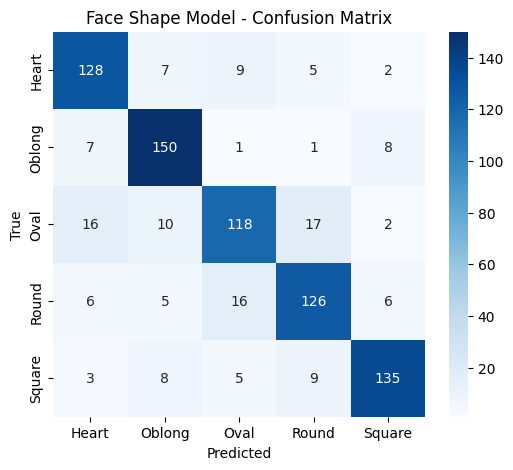


=== Evaluating Eye Shape Model ===
Accuracy:  0.9802
Macro-F1:  0.9804


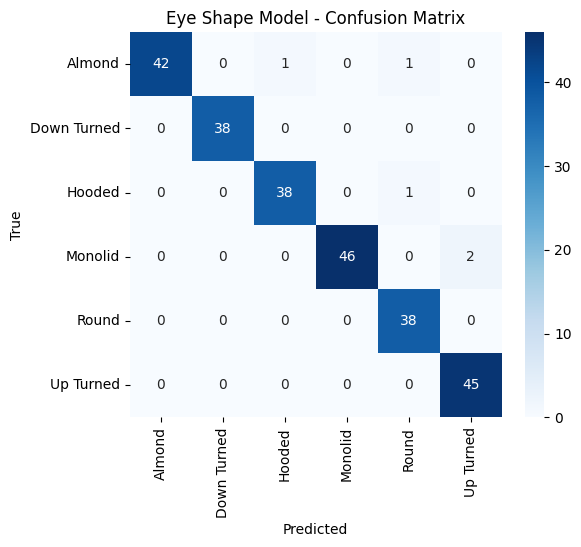

In [ ]:
def evaluate_model(model_path, num_classes, val_loader, classes, title):
    print(f"\n=== Evaluating {title} ===")
    model = build_model(num_classes)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    y_true, y_pred = [],[]
    with torch.no_grad():
        for inputs, labels in val_loader:
            _, preds = torch.max(model(inputs.to(device)), 1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Macro-F1:  {f1_score(y_true, y_pred, average='macro'):.4f}")

    plt.figure(figsize=(6,5))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.title(f'{title} - Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

evaluate_model('/content/best_face_model.pth', len(face_classes), face_val_loader, face_classes, "Face Shape Model")
evaluate_model('/content/best_eye_model.pth', len(eye_classes), eye_val_loader, eye_classes, "Eye Shape Model")

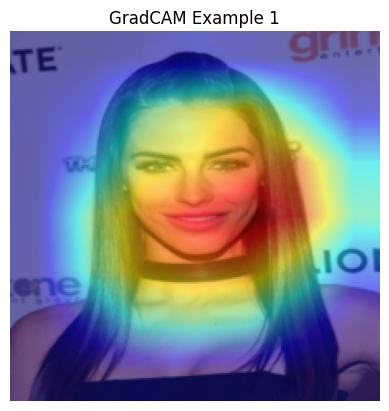

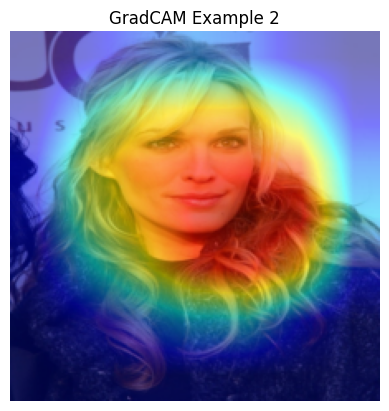

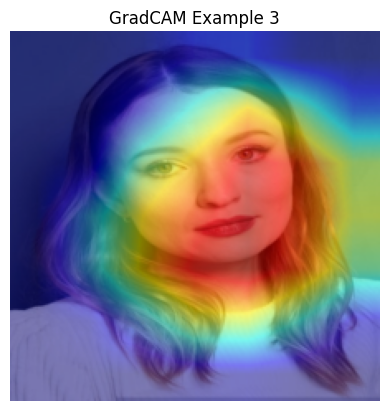

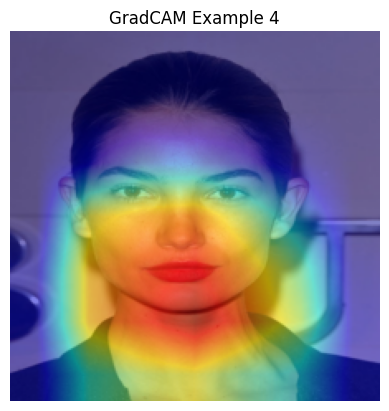

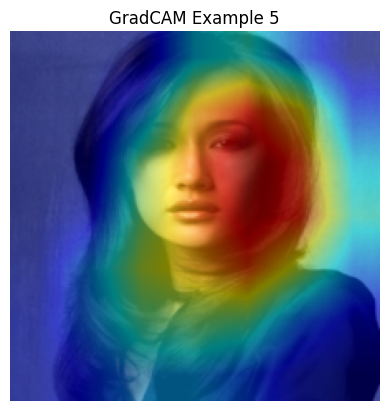

In [ ]:
# Inverse normalization (to convert tensor back to image)
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

def show_gradcam(model_path, num_classes, img_tensor, orig_img_np, title):

    model = build_model(num_classes)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # IMPORTANT: ResNet50 uses layer4, not features
    target_layers = [model.layer4[-1]]

    cam = GradCAM(model=model, target_layers=target_layers)

    grayscale_cam = cam(
        input_tensor=img_tensor.unsqueeze(0).to(device),
        targets=None
    )[0, :]

    cam_image = show_cam_on_image(
        np.float32(orig_img_np) / 255,
        grayscale_cam,
        use_rgb=True
    )

    plt.imshow(cam_image)
    plt.title(title)
    plt.axis("off")
    plt.show()


# Generate Grad-CAM for 5 validation images
for i in range(5):

    img_tensor, _ = face_val_loader.dataset[i]

    orig_img = np.clip(
        inv_normalize(img_tensor)
        .permute(1, 2, 0)
        .numpy() * 255,
        0, 255
    ).astype(np.uint8)

    show_gradcam(
        "/content/best_face_model.pth",
        len(face_classes),
        img_tensor,
        orig_img,
        f"GradCAM Example {i+1}"
    )

In [ ]:
face_infer = build_model(len(face_classes))
face_infer.load_state_dict(torch.load('/content/best_face_model.pth'))
face_infer.eval()

eye_infer = build_model(len(eye_classes))
eye_infer.load_state_dict(torch.load('/content/best_eye_model.pth'))
eye_infer.eval()

# Transparent Rule-Based Mapping
STYLE_MAPPING = {
    "Face Shape": {
        "oval": "Blunt bob or long waves. (Symmetrical shape suits most styles).",
        "square": "Soft, wispy bangs or side-swept parts to soften the jawline.",
        "round": "Long layers or high ponytails to visually elongate the face.",
        "heart": "Side-parted pixie or chin-length bob to balance the forehead.",
        "oblong": "Shoulder-length cuts with volume on the sides to add width."
    },
    "Eye Shape": {
        "almond": "Most styles will compliment this shape so it all depends on what look you are going for. You have great flexibility.",
        "round": "You want to elongate and balance out your eyes. Long, curly, and wispy lashes will do just that.",
        "hooded": "Choose lashes that will create a depth effect that will open the eyes at the center, giving the illusion of bigger, brighter eyes.",
        "monolid": "Choose styles with more flare for openness and length on the outer corners to create an illusion of an elongated eye shape.",
        "down turned": "Choose lashes that extend the outer corners. A pair of elongated lashes will create length along the lash line to help lift your eyes.",
        "up turned": "Choose a flared half-lash or lashes with evenly distributed volume to balance the natural upward lift of your eyes." # (Standard beauty rule added since it wasn't on the chart)
    }
}

def analyze_user_image(image):
    if image is None: return "Please upload an image."

    aligned_face = align_and_crop_face(image)
    if aligned_face is None: return "❌ Error: Could not detect or align a face."

    tensor = val_transforms(Image.fromarray(cv2.cvtColor(aligned_face, cv2.COLOR_BGR2RGB))).unsqueeze(0).to(device)

    with torch.no_grad():
        face_pred = face_classes[torch.argmax(face_infer(tensor)).item()].lower()
        eye_pred = eye_classes[torch.argmax(eye_infer(tensor)).item()].lower()

    face_rec = STYLE_MAPPING["Face Shape"].get(face_pred, "Enhance natural features with layered styles.")
    eye_rec = STYLE_MAPPING["Eye Shape"].get(eye_pred, "Highlight with lengthening mascara.")

    result = f"### 🔍 Analysis Results\n"
    result += f"- **Face Shape Detected:** {face_pred.capitalize()}\n"
    result += f"- **Eye Shape Detected:** {eye_pred.capitalize()}\n\n"
    result += f"### 💡 Style Recommendations\n"
    result += f"- **Hair:** {face_rec}\n"
    result += f"- **Eyelashes:** {eye_rec}\n\n"
    result += "---\n*🔒 Privacy Note: No identifying biometric data or gender profiling was collected during this inference. Image processed ephemerally.*"
    return result

demo = gr.Interface(
    fn=analyze_user_image,
    inputs=gr.Image(type="numpy", label="Upload Photo"),
    outputs=gr.Markdown(label="System Output"),
    title="Face Attribute Analysis and Style Recommendation Tool",
    description="A rule-based, transparent recommendation engine designed with responsible AI principles.",
    allow_flagging="never"
)

# Launch the app! Click the public URL generated below.
demo.launch(share=True, debug=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7b76896b9663266f99.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
